<a href="https://colab.research.google.com/github/gaduhprakoso/PCVK_Ganjil2026/blob/main/week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1 PERCOBAAN HISTOGRAM**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

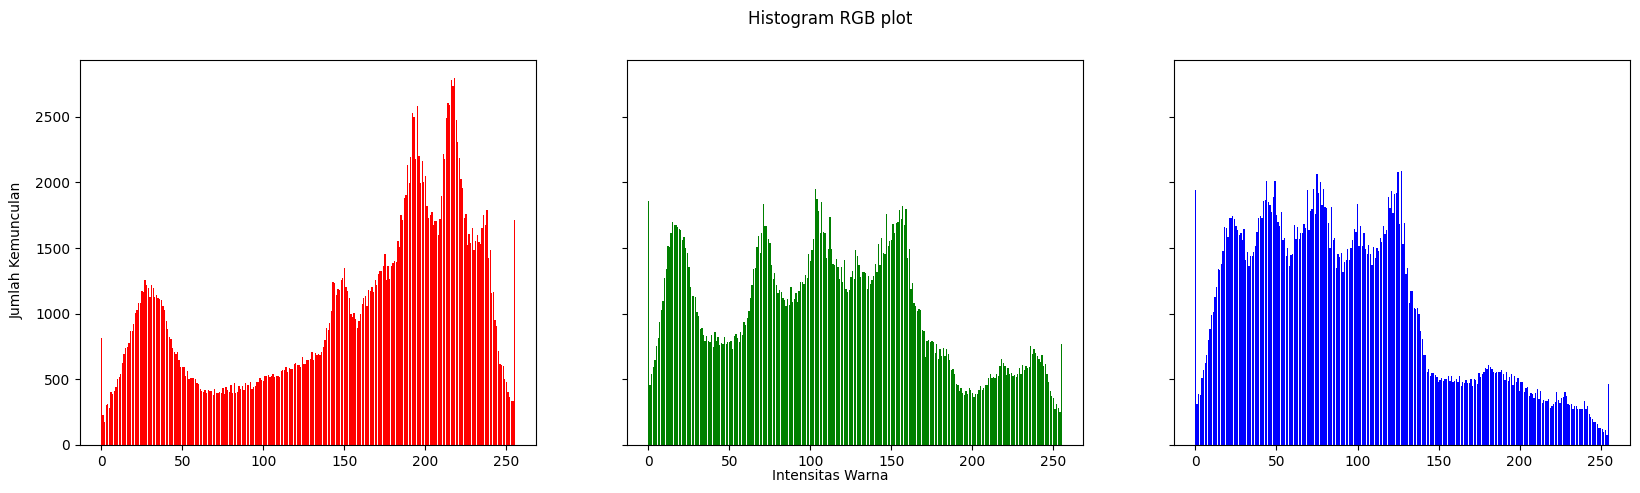

In [4]:
#membuat histogram image LENA
img = cv.imread('/content/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

**2 PERCOBAAN HISTOGRAM EQUALIZATION**

<BarContainer object of 256 artists>

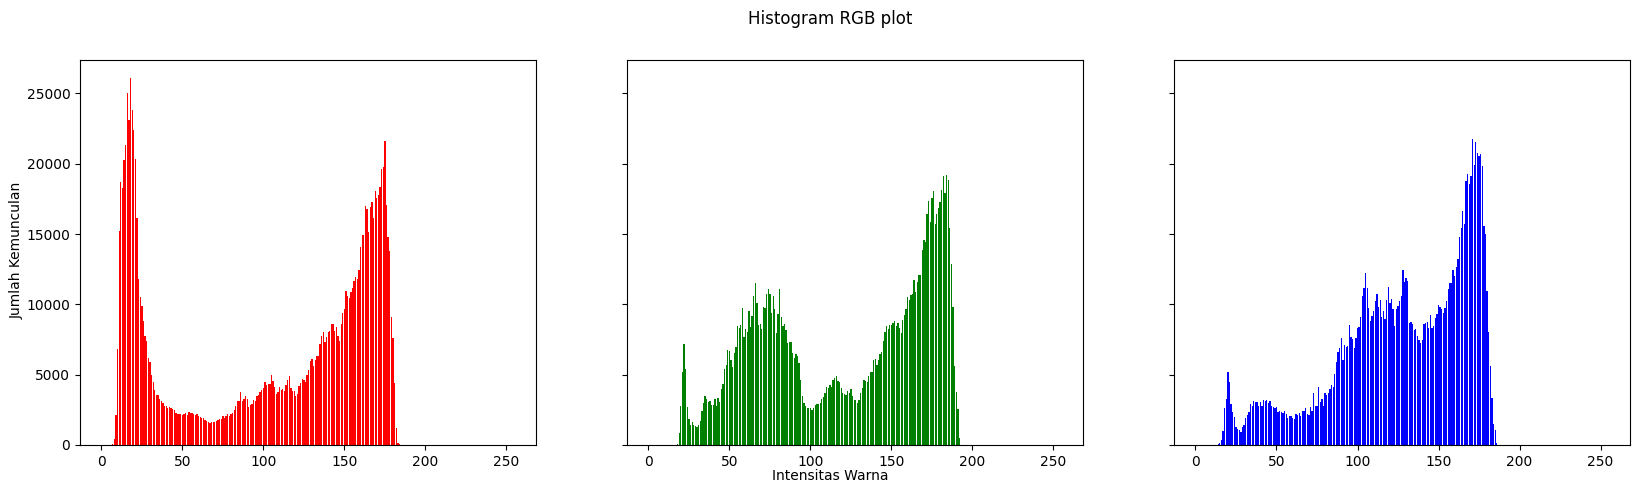

In [7]:
#membuat histogram image KTM
img = cv.imread('/content/ktm.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

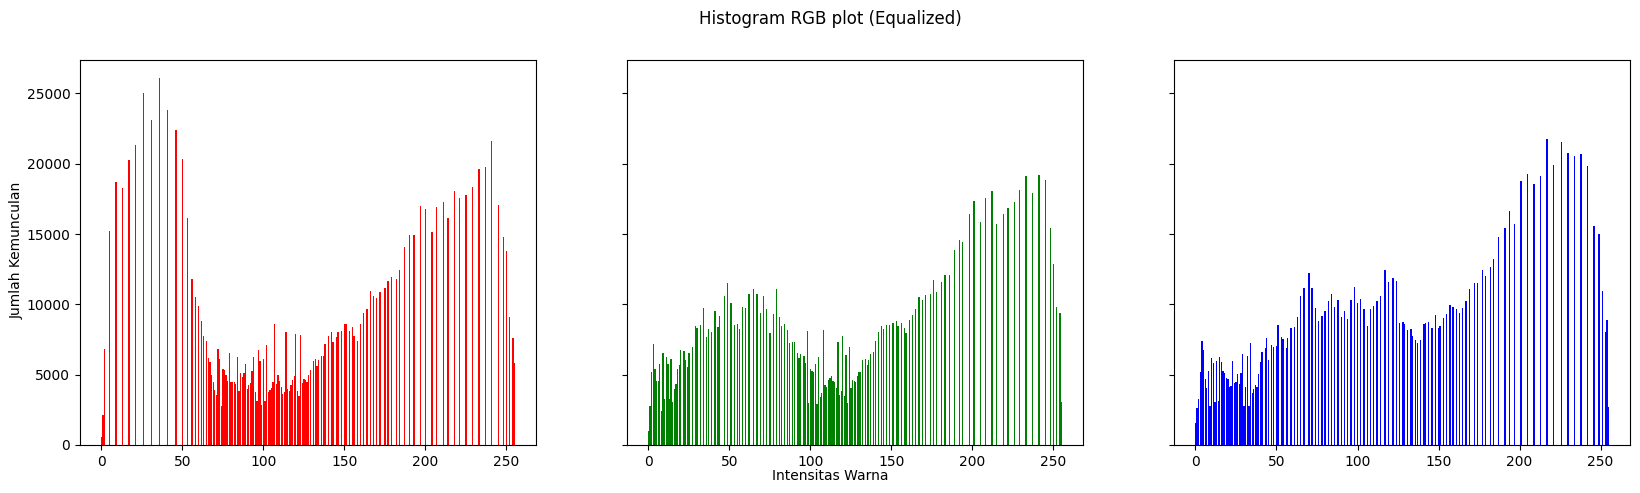

In [10]:
img = cv.imread('/content/ktm.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img)

r_equalized = cv.equalizeHist(r)
g_equalized = cv.equalizeHist(g)
b_equalized = cv.equalizeHist(b)

img_equalized = cv.merge((r_equalized, g_equalized, b_equalized))
height, width, depth = np.shape(img_equalized)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img_equalized[y][x][0]] += 1
        green[img_equalized[y][x][1]] += 1
        blue[img_equalized[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (Equalized)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

In [12]:
def manual_equalization(channel):
    hist, _ = np.histogram(channel.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf_final[channel]

r_manual = manual_equalization(r)
g_manual = manual_equalization(g)
b_manual = manual_equalization(b)

diff_r = np.max(np.abs(r_equalized.astype(int) - r_manual.astype(int)))
diff_g = np.max(np.abs(g_equalized.astype(int) - g_manual.astype(int)))
diff_b = np.max(np.abs(b_equalized.astype(int) - b_manual.astype(int)))

print(f"Selisih maksimum channel Red   : {diff_r}")
print(f"Selisih maksimum channel Green : {diff_g}")
print(f"Selisih maksimum channel Blue  : {diff_b}")

Selisih maksimum channel Red   : 1
Selisih maksimum channel Green : 1
Selisih maksimum channel Blue  : 1


Selisih tersebut terjadi murni karena perbedaan cara pembulatan angka desimal:

*   Python (Manual): Membulatkan nilai desimal tengah (0,5) ke angka genap terdekat
*   OpenCV (Bawaan): Membulatkan angka ke atas atau langsung memotong nilai desimalnya agar proses perhitungan berjalan jauh lebih cepat.

Perbedaan cara membulatkan angka inilah yang membuat hasil akhir bergeser 1 level intensitas warna, meskipun secara visual pada gambar sama sekali tidak terlihat bedanya oleh mata manusia

cara 1: tiap kanal diekualisasi sendiri-sendiri

In [25]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt

berkas = '/content/lena.jpg'
bgr    = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

In [17]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt

berkas = '/content/ktm.jpeg'
bgr    = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

cara 2: hanya kanal terang yang diekualisasi

In [26]:
# cara 2: hanya kanal terang yang diekualisasi
ycrcb   = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# varian setara pada ruang warna lain
hsv       = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab       = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b   = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

In [23]:
NIM = "244107020150"

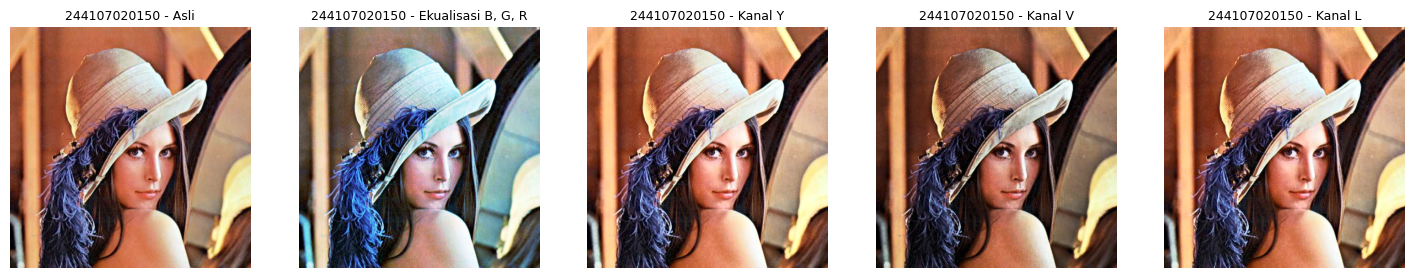

In [27]:
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

In [28]:
# Daftar citra dan nama metodenya
citra_list = [bgr, he_rgb, he_y, he_v, he_l]
nama_metode = ['Citra asli', 'Ekualisasi B, G, R', 'Kanal Y (YCrCb)', 'Kanal V (HSV)', 'Kanal L (LAB)']

# Konversi citra asli ke HSV untuk referensi perhitungan Hue
hsv_asli = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h_asli = hsv_asli[:,:,0].astype(np.float32) * 2

print(f"{'Cara Ekualisasi':<25} | {'Pergeseran Hue (derajat)':<25} | {'Rerata Kecerahan'}")
print("-" * 75)

for nama, img in zip(nama_metode, citra_list):
    hsv_img = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    rerata_kecerahan = np.mean(hsv_img[:,:,2])

    if nama == 'Citra asli':
        pergeseran_hue = 0.0
    else:
        h_img = hsv_img[:,:,0].astype(np.float32) * 2
        diff = np.abs(h_img - h_asli)
        diff = np.minimum(diff, 360 - diff)
        pergeseran_hue = np.mean(diff)

    print(f"{nama:<25} | {pergeseran_hue:<25.2f} | {rerata_kecerahan:.2f}")

Cara Ekualisasi           | Pergeseran Hue (derajat)  | Rerata Kecerahan
---------------------------------------------------------------------------
Citra asli                | 0.00                      | 157.75
Ekualisasi B, G, R        | 53.03                     | 148.42
Kanal Y (YCrCb)           | 0.40                      | 163.03
Kanal V (HSV)             | 0.87                      | 128.18
Kanal L (LAB)             | 1.65                      | 157.64


PERTANYAAN PRAKTIKUM E2

kualisasi global pada citra KTM Anda



*   a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.
*   b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.
*   c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR layak dipakai untuk menilai keterbacaan sebuah citra.


/tmp/ipykernel_3767/1825642277.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[0, 1].hist(img.flatten(), 256, [0, 256], color='black')
/tmp/ipykernel_3767/1825642277.py:26: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(eq_cv.flatten(), 256, [0, 256], color='black')


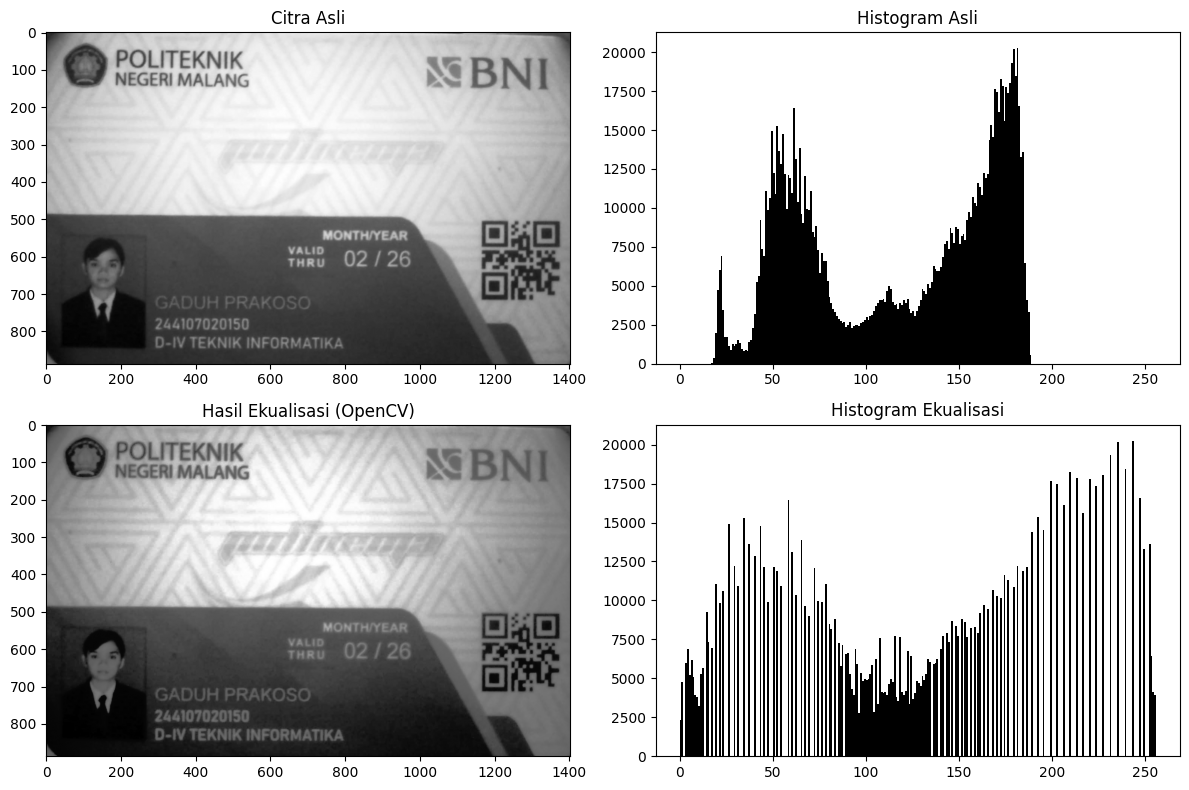

Nilai PSNR: 19.29 dB


In [30]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# a. Membaca citra grayscale dan melakukan ekualisasi
img = cv.imread('/content/ktm.jpeg', cv.IMREAD_GRAYSCALE)

eq_cv = cv.equalizeHist(img)

hist, _ = np.histogram(img.flatten(), 256, [0,256])
cdf = hist.cumsum()
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
eq_manual = np.ma.filled(cdf_m, 0).astype('uint8')[img]

# b. Menampilkan citra dan histogram dalam satu layout
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].imshow(img, cmap='gray')
axs[0, 0].set_title('Citra Asli')
axs[0, 1].hist(img.flatten(), 256, [0, 256], color='black')
axs[0, 1].set_title('Histogram Asli')

axs[1, 0].imshow(eq_cv, cmap='gray')
axs[1, 0].set_title('Hasil Ekualisasi (OpenCV)')
axs[1, 1].hist(eq_cv.flatten(), 256, [0, 256], color='black')
axs[1, 1].set_title('Histogram Ekualisasi')

plt.tight_layout()
plt.show()

# c. Menghitung PSNR
psnr_value = cv.PSNR(img, eq_cv)
print(f"Nilai PSNR: {psnr_value:.2f} dB")

Mengapa nilai PSNR turun?
* PSNR (Peak Signal-to-Noise Ratio) secara matematis mengukur kemiripan atau selisih nilai piksel antara gambar hasil dengan gambar asli (semakin banyak piksel yang berubah, PSNR makin kecil). Ekualisasi memang sengaja merombak drastis nilai piksel untuk meningkatkan kontras. Rumus PSNR menganggap perubahan drastis ini sebagai sebuah "error" atau "kerusakan", sehingga nilainya menjadi anjlok.

Apakah PSNR layak dipakai menilai keterbacaan?
* Tidak layak. PSNR digunakan untuk mengukur seberapa setia sebuah gambar terhadap aslinya (misalnya untuk mengukur kualitas kompresi file atau kejernihan setelah menghapus noise), bukan untuk mengukur tingkat kontras, estetika, atau seberapa jelas teks dapat dibaca oleh mata manusia.

Ekualisasi lokal dengan CLAHE pada citra KTM Anda

*   a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?
*   b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang noise-nya mulai menonjol ketika clipLimit dinaikkan.



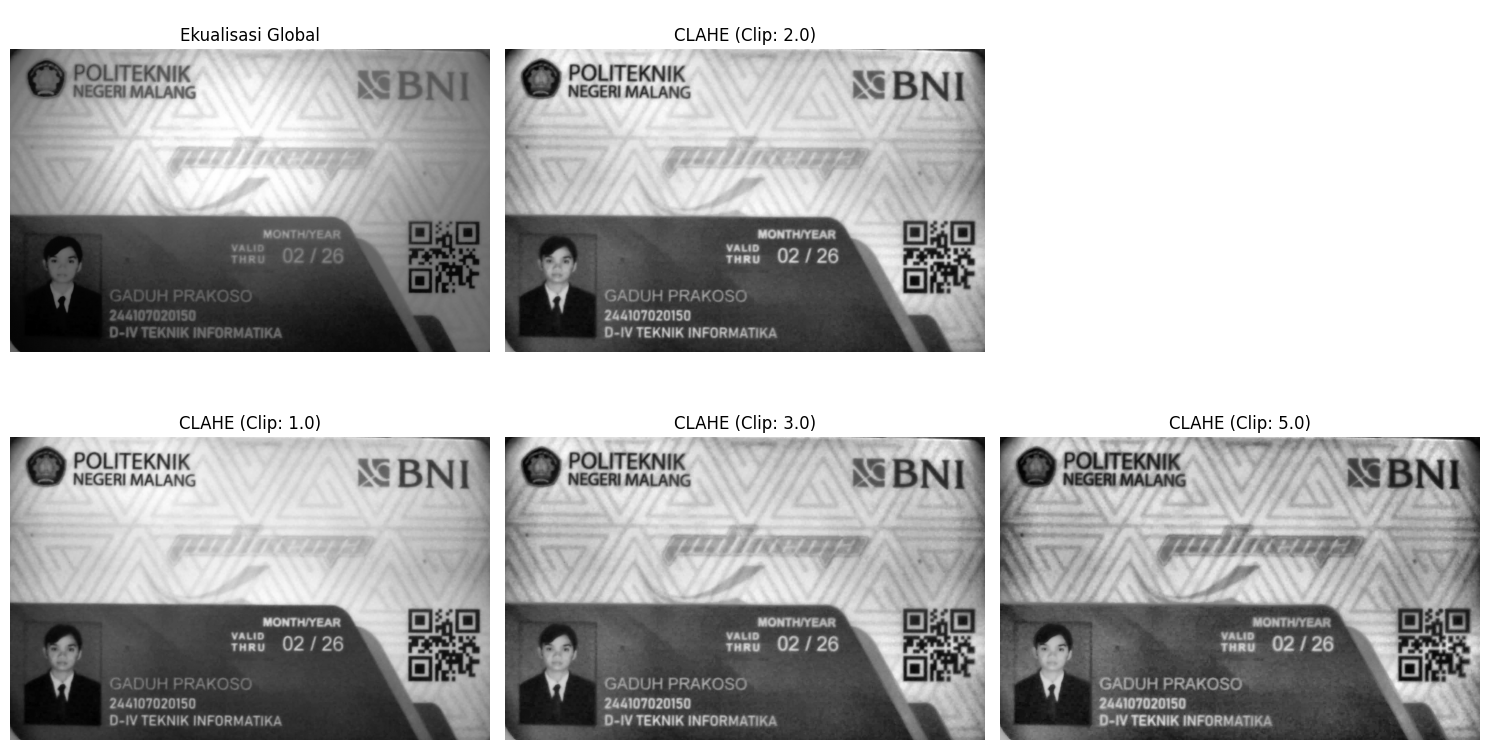

In [31]:
import cv2 as cv
import matplotlib.pyplot as plt

clip_base = 2.0
tile_size = 8

img = cv.imread('/content/ktm.jpeg', cv.IMREAD_GRAYSCALE)

# a. Ekualisasi Global vs CLAHE
eq_global = cv.equalizeHist(img)
clahe_base = cv.createCLAHE(clipLimit=clip_base, tileGridSize=(tile_size, tile_size))
eq_clahe_base = clahe_base.apply(img)

# b. Percobaan 3 nilai clipLimit lain (misal: 1.0, 3.0, 4.0)
clahe_1 = cv.createCLAHE(clipLimit=1.0, tileGridSize=(tile_size, tile_size))
eq_clahe_1 = clahe_1.apply(img)

clahe_3 = cv.createCLAHE(clipLimit=3.0, tileGridSize=(tile_size, tile_size))
eq_clahe_3 = clahe_3.apply(img)

clahe_4 = cv.createCLAHE(clipLimit=5.0, tileGridSize=(tile_size, tile_size))
eq_clahe_4 = clahe_4.apply(img)

# Menampilkan semua hasil perbandingan
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs[0, 0].imshow(eq_global, cmap='gray'); axs[0, 0].set_title('Ekualisasi Global')
axs[0, 1].imshow(eq_clahe_base, cmap='gray'); axs[0, 1].set_title(f'CLAHE (Clip: {clip_base})')
axs[0, 2].axis('off')

axs[1, 0].imshow(eq_clahe_1, cmap='gray'); axs[1, 0].set_title('CLAHE (Clip: 1.0)')
axs[1, 1].imshow(eq_clahe_3, cmap='gray'); axs[1, 1].set_title('CLAHE (Clip: 3.0)')
axs[1, 2].imshow(eq_clahe_4, cmap='gray'); axs[1, 2].set_title('CLAHE (Clip: 5.0)')

for ax in axs.flat:
    if ax.has_data(): ax.axis('off')
plt.tight_layout()
plt.show()

a. Mana yang lebih terbaca?
* Tulisan NIM dan nama jauh lebih terbaca pada hasil CLAHE. Ekualisasi global merusak gambar karena membuat area terang menjadi terlalu silau (overexposed) dan menyamarkan teks, sedangkan CLAHE mengatur kontras pada area-area kecil sehingga teks tetap tajam dan jelas.

b. Nilai terbaik dan efek menaikkan clipLimit:
* Nilai terbaik: Biasanya di angka 2.0 atau 3.0. Pada rentang ini, teks menjadi sangat kontras dan jelas dibaca, namun gambar secara keseluruhan masih terlihat natural.

**3 TUGAS PRAKTIKUM DITHERING**

Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi pada KTM1b.jpg dengan jumlah level PARAM['L'].

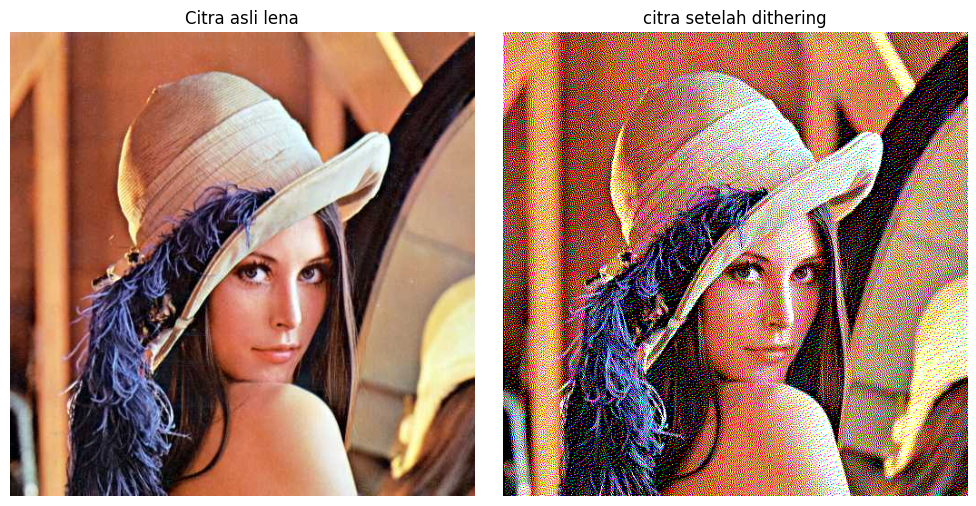

In [36]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg_color(img, levels=2):
    dithered = img.astype(float)
    h, w, c = dithered.shape

    factor = 255.0 / (levels - 1)

    for y in range(h):
        for x in range(w):
            old_pixel = dithered[y, x].copy()

            new_pixel = np.round(old_pixel / factor) * factor
            dithered[y, x] = new_pixel

            error = old_pixel - new_pixel

            if x + 1 < w:
                dithered[y, x + 1] += error * 7 / 16
            if y + 1 < h:
                if x - 1 >= 0:
                    dithered[y + 1, x - 1] += error * 3 / 16
                dithered[y + 1, x] += error * 5 / 16
                if x + 1 < w:
                    dithered[y + 1, x + 1] += error * 1 / 16

    return np.clip(dithered, 0, 255).astype(np.uint8)

img = cv.imread('lena.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

dither = floyd_steinberg_color(img_rgb, levels=2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img_rgb)
axs[0].set_title('Citra asli lena')
axs[0].axis('off')

axs[1].imshow(dither)
axs[1].set_title('citra setelah dithering')
axs[1].axis('off')

plt.tight_layout()
plt.show()

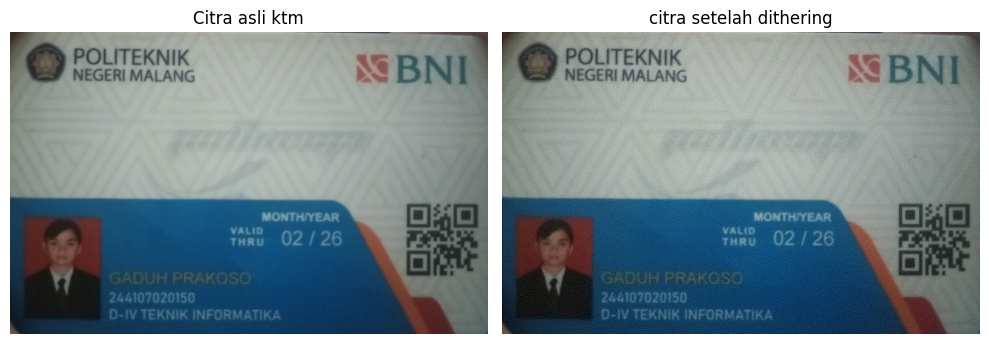

In [37]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg_color(img, levels=2):
    dithered = img.astype(float)
    h, w, c = dithered.shape

    factor = 255.0 / (levels - 1)

    for y in range(h):
        for x in range(w):
            old_pixel = dithered[y, x].copy()

            new_pixel = np.round(old_pixel / factor) * factor
            dithered[y, x] = new_pixel

            error = old_pixel - new_pixel

            if x + 1 < w:
                dithered[y, x + 1] += error * 7 / 16
            if y + 1 < h:
                if x - 1 >= 0:
                    dithered[y + 1, x - 1] += error * 3 / 16
                dithered[y + 1, x] += error * 5 / 16
                if x + 1 < w:
                    dithered[y + 1, x + 1] += error * 1 / 16

    return np.clip(dithered, 0, 255).astype(np.uint8)

img = cv.imread('ktm.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

dither = floyd_steinberg_color(img_rgb, levels=2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img_rgb)
axs[0].set_title('Citra asli ktm')
axs[0].axis('off')

axs[1].imshow(dither)
axs[1].set_title('citra setelah dithering')
axs[1].axis('off')

plt.tight_layout()
plt.show()

 Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang menghasilkan teks pada KTM lebih terbaca.

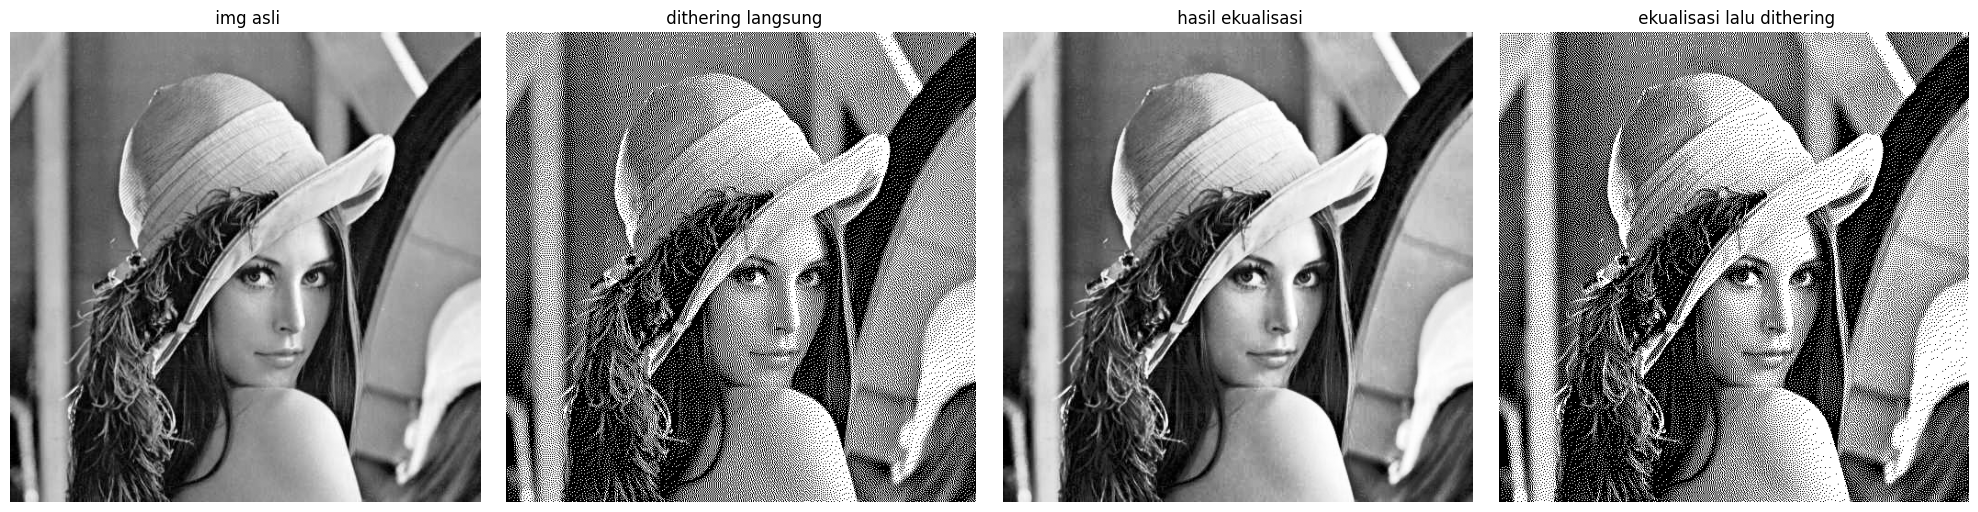

In [39]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg_grayscale(img, levels=2):
    dithered = img.astype(float)
    h, w = dithered.shape
    factor = 255.0 / (levels - 1)

    for y in range(h):
        for x in range(w):
            old_pixel = dithered[y, x]
            new_pixel = np.round(old_pixel / factor) * factor
            dithered[y, x] = new_pixel

            error = old_pixel - new_pixel

            if x + 1 < w: dithered[y, x + 1] += error * 7 / 16
            if y + 1 < h:
                if x - 1 >= 0: dithered[y + 1, x - 1] += error * 3 / 16
                dithered[y + 1, x] += error * 5 / 16
                if x + 1 < w: dithered[y + 1, x + 1] += error * 1 / 16

    return np.clip(dithered, 0, 255).astype(np.uint8)

img = cv.imread('lena.jpg', cv.IMREAD_GRAYSCALE)

dither_langsung = floyd_steinberg_grayscale(img, levels=2)

eq = cv.equalizeHist(img)

eq_dither = floyd_steinberg_grayscale(eq, levels=2)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axs[0].set_title(' img asli')

axs[1].imshow(dither_langsung, cmap='gray', vmin=0, vmax=255)
axs[1].set_title(' dithering langsung')

axs[2].imshow(eq, cmap='gray', vmin=0, vmax=255)
axs[2].set_title(' hasil ekualisasi')

axs[3].imshow(eq_dither, cmap='gray', vmin=0, vmax=255)
axs[3].set_title(' ekualisasi lalu dithering')

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

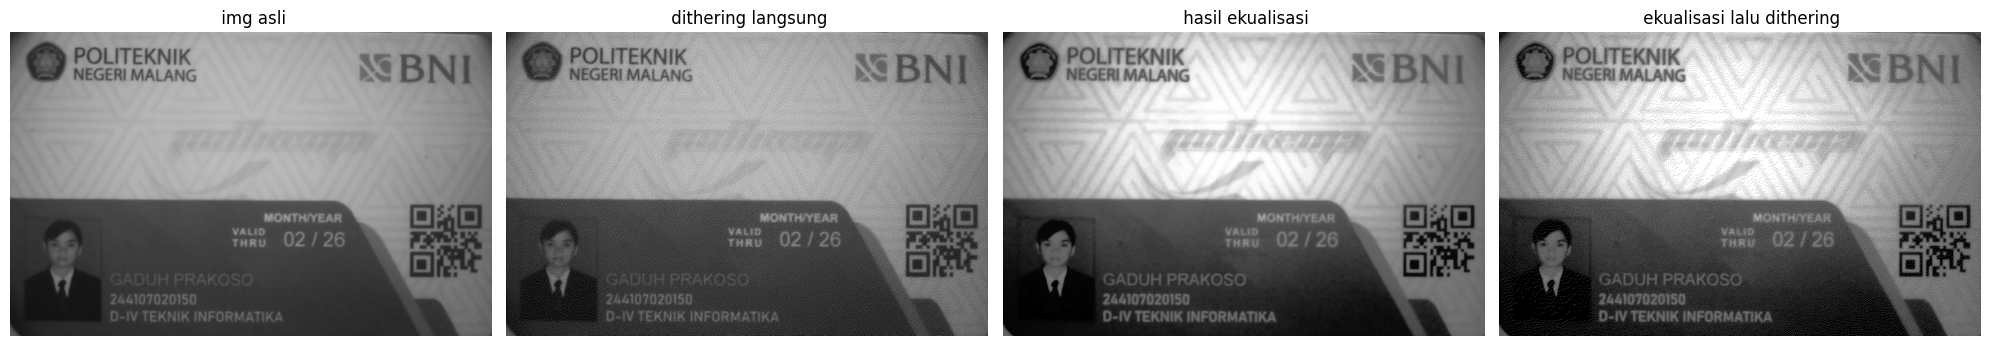

In [40]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg_grayscale(img, levels=2):
    dithered = img.astype(float)
    h, w = dithered.shape
    factor = 255.0 / (levels - 1)

    for y in range(h):
        for x in range(w):
            old_pixel = dithered[y, x]
            new_pixel = np.round(old_pixel / factor) * factor
            dithered[y, x] = new_pixel

            error = old_pixel - new_pixel

            if x + 1 < w: dithered[y, x + 1] += error * 7 / 16
            if y + 1 < h:
                if x - 1 >= 0: dithered[y + 1, x - 1] += error * 3 / 16
                dithered[y + 1, x] += error * 5 / 16
                if x + 1 < w: dithered[y + 1, x + 1] += error * 1 / 16

    return np.clip(dithered, 0, 255).astype(np.uint8)

img = cv.imread('ktm.jpeg', cv.IMREAD_GRAYSCALE)

dither_langsung = floyd_steinberg_grayscale(img, levels=2)

eq = cv.equalizeHist(img)

eq_dither = floyd_steinberg_grayscale(eq, levels=2)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axs[0].set_title(' img asli')

axs[1].imshow(dither_langsung, cmap='gray', vmin=0, vmax=255)
axs[1].set_title(' dithering langsung')

axs[2].imshow(eq, cmap='gray', vmin=0, vmax=255)
axs[2].set_title(' hasil ekualisasi')

axs[3].imshow(eq_dither, cmap='gray', vmin=0, vmax=255)
axs[3].set_title(' ekualisasi lalu dithering')

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()